In [48]:
from ovito.io import import_file
from ovito.modifiers import RadialDistributionFunctionModifier, TimeAveragingModifier

dump_path = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod_coarse.out"

pipeline = import_file(dump_path)

data = pipeline.compute()

ptype_prop = data.particles_.particle_types_

ptype_prop.type_by_id_(1).name = "O"
ptype_prop.type_by_id_(2).name = "H"

radius_cutoff = 10
bins = 500

In [49]:
pipeline.modifiers.append(
    RadialDistributionFunctionModifier(
        cutoff=radius_cutoff,
        number_of_bins=bins,
        partial=True
    )
)

pipeline.modifiers.append(
    TimeAveragingModifier(
        operate_on='table:coordination-rdf'
    )
)

data = pipeline.compute()

avg_table = data.tables['coordination-rdf[average]']

xy = avg_table.xy()

r = xy[:,0]
rdf_avg = xy[:,1:]

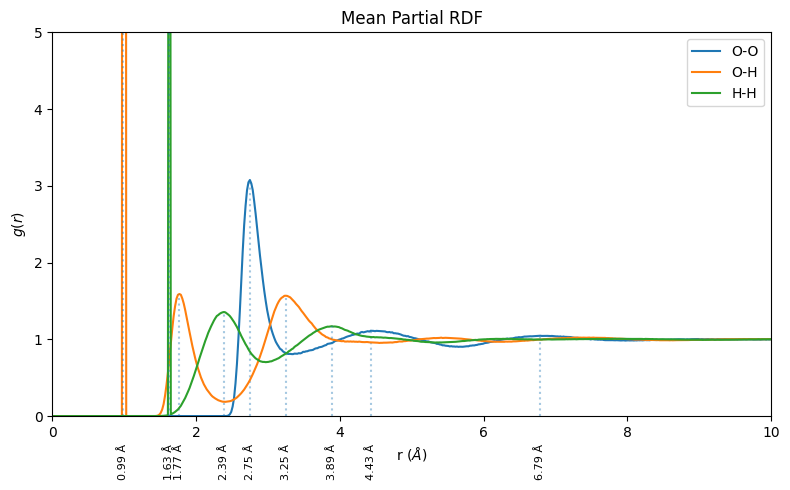

In [56]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

pair_names = ["O-O", "O-H", "H-H"]

plt.figure(figsize=(8,5))

for i, pair in enumerate(pair_names):

    y = rdf_avg[:, i]

    plt.plot(r, y, label=pair)

    # Find peaks
    peaks, properties = find_peaks(
        y,
        prominence=0.05,
        distance=5        # minimum bins between peaks
    )

    # Label first few strongest peaks
    peak_heights = y[peaks]
    strongest = peaks[np.argsort(peak_heights)[::-1][:3]]

    ax = plt.gca()

    for p in strongest:
        x_peak = r[p]
        y_peak = y[p]

        ax.vlines(
            x_peak,
            ymin=0,
            ymax=y_peak,
            linestyle=':',
            alpha=0.4
        )

        ax.annotate(
            f"{x_peak:.2f} Å",
            xy=(x_peak, 0),
            xycoords='data',
            xytext=(0, -20),
            textcoords='offset points',
            ha='center',
            va='top',
            rotation=90,
            fontsize=8,
            annotation_clip=False
        )

plt.xlabel(r"r ($\AA$)")
plt.ylabel(r"$g(r)$")
plt.xlim(0, radius_cutoff)
plt.ylim(0, 5)
plt.title("Mean Partial RDF")
plt.legend()
plt.tight_layout()
plt.show()

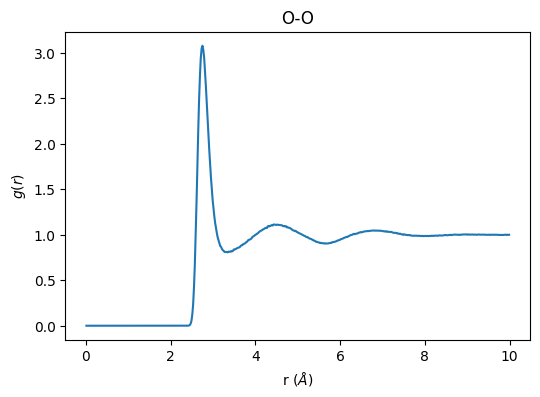

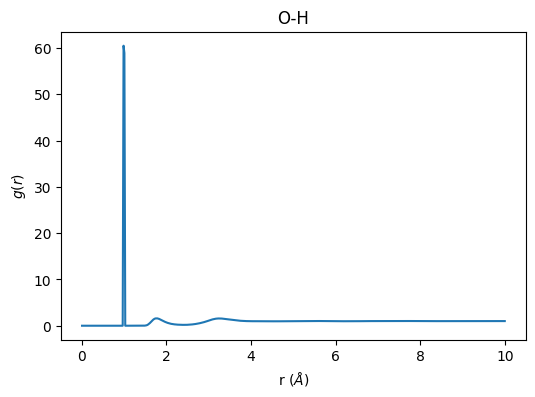

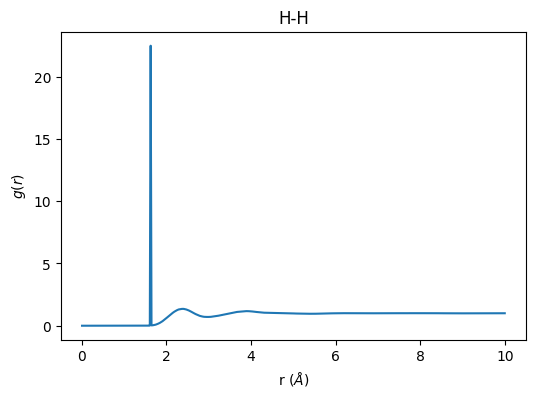

In [51]:
for i, pair in enumerate(pair_names):

    plt.figure(figsize=(6,4))
    plt.plot(r, rdf_avg[:,i])

    plt.title(pair)
    plt.xlabel(r"r ($\AA$)")
    plt.ylabel(r"$g(r)$")

    plt.show()